In [1]:
import requests
import pandas as pd
import datetime
import time
from typing import List, Dict, Optional, Union
import matplotlib.pyplot as plt

In [2]:
class BinanceInvestorAnalyzer:
    """
    Binance API를 활용하여 롱/숏 포지션별 투자자 유형(기관/개인) 비율을 분석하는 클래스
    """
    
    def __init__(self, api_key: Optional[str] = None, api_secret: Optional[str] = None):
        """
        초기화 메서드
        
        Args:
            api_key: Binance API 키 (선택적, 퍼블릭 API만 사용할 경우 필요 없음)
            api_secret: Binance API 시크릿 (선택적, 퍼블릭 API만 사용할 경우 필요 없음)
        """
        self.base_url = "https://fapi.binance.com"
        self.api_key = api_key
        self.api_secret = api_secret
        self.headers = {}
        
        if api_key:
            self.headers["X-MBX-APIKEY"] = api_key
    
    def get_available_symbols(self) -> List[str]:
        """
        사용 가능한 선물 거래 심볼 목록을 가져옵니다.
        
        Returns:
            List[str]: 사용 가능한 심볼 목록
        """
        endpoint = "/fapi/v1/exchangeInfo"
        response = requests.get(f"{self.base_url}{endpoint}")
        data = response.json()
        
        symbols = [symbol["symbol"] for symbol in data["symbols"] if symbol["status"] == "TRADING"]
        return symbols
    
    def get_global_long_short_data(self, symbol: str, period: str = "1d", limit: int = 30) -> pd.DataFrame:
        """
        글로벌 롱/숏 데이터를 가져옵니다.
        
        Args:
            symbol: 암호화폐 심볼 (예: 'BTCUSDT', 'ETHUSDT' 등)
            period: 데이터 기간 ('5m', '15m', '30m', '1h', '2h', '4h', '6h', '12h', '1d')
            limit: 반환할 데이터 수 (최대 500)
            
        Returns:
            pd.DataFrame: 포지션 데이터
        """
        endpoint = "/futures/data/globalLongShortAccountRatio"
        params = {
            "symbol": symbol,
            "period": period,
            "limit": limit
        }
        
        response = requests.get(f"{self.base_url}{endpoint}", params=params)
        data = response.json()
        
        if not data:
            print(f"No data available for {symbol}")
            return pd.DataFrame()
        
        df = pd.DataFrame(data)
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        df['longShortRatio'] = df['longShortRatio'].astype(float)
        df['longAccount'] = df['longAccount'].astype(float) * 100  # 백분율로 변환
        df['shortAccount'] = df['shortAccount'].astype(float) * 100  # 백분율로 변환
        df['symbol'] = symbol
        
        return df
    
    def get_top_trader_long_short_data(self, symbol: str, period: str = "1d", limit: int = 30) -> pd.DataFrame:
        """
        상위 트레이더(기관) 롱/숏 데이터를 가져옵니다.
        
        Args:
            symbol: 암호화폐 심볼 (예: 'BTCUSDT', 'ETHUSDT' 등)
            period: 데이터 기간 ('5m', '15m', '30m', '1h', '2h', '4h', '6h', '12h', '1d')
            limit: 반환할 데이터 수 (최대 500)
            
        Returns:
            pd.DataFrame: 상위 트레이더 포지션 데이터
        """
        endpoint = "/futures/data/topLongShortAccountRatio"
        params = {
            "symbol": symbol,
            "period": period,
            "limit": limit
        }
        
        response = requests.get(f"{self.base_url}{endpoint}", params=params)
        data = response.json()
        
        if not data:
            print(f"No data available for {symbol}")
            return pd.DataFrame()
        
        df = pd.DataFrame(data)
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        df['longShortRatio'] = df['longShortRatio'].astype(float)
        df['longAccount'] = df['longAccount'].astype(float) * 100  # 백분율로 변환
        df['shortAccount'] = df['shortAccount'].astype(float) * 100  # 백분율로 변환
        df['symbol'] = symbol
        
        return df
    
    def get_top_trader_positions_data(self, symbol: str, period: str = "1d", limit: int = 30) -> pd.DataFrame:
        """
        상위 트레이더(기관) 포지션 데이터를 가져옵니다.
        
        Args:
            symbol: 암호화폐 심볼 (예: 'BTCUSDT', 'ETHUSDT' 등)
            period: 데이터 기간 ('5m', '15m', '30m', '1h', '2h', '4h', '6h', '12h', '1d')
            limit: 반환할 데이터 수 (최대 500)
            
        Returns:
            pd.DataFrame: 상위 트레이더 포지션 데이터
        """
        endpoint = "/futures/data/topLongShortPositionRatio"
        params = {
            "symbol": symbol,
            "period": period,
            "limit": limit
        }
        
        response = requests.get(f"{self.base_url}{endpoint}", params=params)
        data = response.json()
        
        if not data:
            print(f"No data available for {symbol}")
            return pd.DataFrame()
        
        df = pd.DataFrame(data)
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        df['longShortRatio'] = df['longShortRatio'].astype(float)
        df['longAccount'] = df['longAccount'].astype(float) * 100  # 백분율로 변환
        df['shortAccount'] = df['shortAccount'].astype(float) * 100  # 백분율로 변환
        df['symbol'] = symbol
        
        return df
    
    def calculate_investor_ratio_by_position(self, symbol: str, period: str = "1d", limit: int = 30) -> pd.DataFrame:
        """
        롱/숏 포지션별 투자자 유형(기관/개인) 비율을 계산합니다.
        
        Args:
            symbol: 암호화폐 심볼 (예: 'BTCUSDT', 'ETHUSDT' 등)
            period: 데이터 기간 ('5m', '15m', '30m', '1h', '2h', '4h', '6h', '12h', '1d')
            limit: 반환할 데이터 수 (최대 500)
            
        Returns:
            pd.DataFrame: 롱/숏 포지션별 투자자 유형 비율 데이터
        """
        # 전체 데이터 (global account ratio)
        global_data = self.get_global_long_short_data(symbol, period, limit)
        
        # 기관 투자자 데이터 (top trader position ratio)
        institution_data = self.get_top_trader_positions_data(symbol, period, limit)
        
        if global_data.empty or institution_data.empty:
            return pd.DataFrame()
        
        # 날짜별로 데이터 병합
        result_df = pd.merge(global_data, institution_data, on='timestamp', suffixes=('_global', '_institution'))
        
        # 롱 포지션에서 기관 투자자 비율 (%)
        result_df['long_institution_ratio'] = result_df['longAccount_institution']
        
        # 롱 포지션에서 개인 투자자 비율 (%) = 100% - 기관 비율
        result_df['long_retail_ratio'] = 100 - result_df['long_institution_ratio']
        
        # 숏 포지션에서 기관 투자자 비율 (%)
        result_df['short_institution_ratio'] = result_df['shortAccount_institution']
        
        # 숏 포지션에서 개인 투자자 비율 (%) = 100% - 기관 비율
        result_df['short_retail_ratio'] = 100 - result_df['short_institution_ratio']
        
        # 필요한 열만 선택
        result_df = result_df[['timestamp', 'symbol_global', 
                              'long_institution_ratio', 'long_retail_ratio',
                              'short_institution_ratio', 'short_retail_ratio']]
        
        # 열 이름 정리
        result_df = result_df.rename(columns={'symbol_global': 'symbol'})
        
        return result_df
    
    def get_all_investor_ratios(self, symbols: List[str], period: str = "1d", limit: int = 30) -> Dict[str, pd.DataFrame]:
        """
        여러 암호화폐에 대한 롱/숏 포지션별 투자자 유형 비율 데이터를 가져옵니다.
        
        Args:
            symbols: 분석할 암호화폐 심볼 목록
            period: 데이터 기간
            limit: 반환할 데이터 수
            
        Returns:
            Dict[str, pd.DataFrame]: 각 심볼별 투자자 유형 비율 데이터
        """
        result = {}
        
        for symbol in symbols:
            print(f"가져오는 중: {symbol}")
            
            # 롱/숏 포지션별 투자자 유형 비율 계산
            ratio_data = self.calculate_investor_ratio_by_position(symbol, period, limit)
            
            if not ratio_data.empty:
                result[symbol] = ratio_data
            
            # API 호출 제한 방지를 위해 약간의 딜레이
            time.sleep(0.5)
        
        return result
    
    def visualize_combined_investor_ratio(self, data: pd.DataFrame, symbol: str):
        """
        롱/숏 포지션에서의 투자자 유형 비율을 하나의 그래프로 시각화
        
        Args:
            data: 시각화할 데이터
            symbol: 암호화폐 심볼
            
        Returns:
            matplotlib.figure.Figure: 생성된 그래프
        """
        fig, ax = plt.subplots(figsize=(10, 7))
        font_size = 16
        
        # 롱 포지션 데이터 (양수 값)
        ax.fill_between(data['timestamp'], 0, data['long_institution_ratio'], 
                        label='Institutional Investors (Long)', color='#1f77b4', alpha=0.7)
        ax.fill_between(data['timestamp'], data['long_institution_ratio'], 100, 
                        label='Retail Investors (Long)', color='#ff7f0e', alpha=0.7)
        
        # 숏 포지션 데이터 (음수 값으로 변환)
        ax.fill_between(data['timestamp'], 0, -data['short_institution_ratio'], 
                        label='Institutional Investors (Short)', color='#1f77b4', alpha=0.7, hatch='/')
        ax.fill_between(data['timestamp'], -data['short_institution_ratio'], -100, 
                        label='Retail Investors (Short)', color='#ff7f0e', alpha=0.7, hatch='/')
        
        # 그래프 설정
        ax.set_title(f'{symbol} Long/Short Position Investor Type Ratio', fontsize=font_size)
        ax.set_xlabel('Date', fontsize=font_size)
        ax.set_ylabel('Ratio (%)', fontsize=font_size)
        ax.set_ylim(-100, 100)
        ax.grid(True, alpha=0.3)
        
        # 0선 강조
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
        
        # y축 레이블 조정
        ax.set_yticks([-100, -75, -50, -25, 0, 25, 50, 75, 100])
        ax.set_yticklabels(['100', '75', '50', '25', '0', '25', '50', '75', '100'], fontsize=font_size-2)
        
        # 범례 추가
        ax.legend(loc='lower right', fontsize=font_size-2)
        ax.tick_params(axis='x', rotation=45, labelsize=font_size-2)
        
        # 설명 텍스트 추가
        ax.text(0.02, 0.95, 'Long Position', transform=ax.transAxes, fontsize=font_size-4)
        ax.text(0.02, 0.05, 'Short Position', transform=ax.transAxes, fontsize=font_size-4)
        
        plt.tight_layout()
        
        return plt

가져오는 중: BTCUSDT
가져오는 중: ETHUSDT
가져오는 중: SOLUSDT
가져오는 중: BNBUSDT

===== BTCUSDT Investor Type Analysis =====
Long Position: Institutional 64.35%, Retail 35.65%
Short Position: Institutional 35.65%, Retail 64.35%


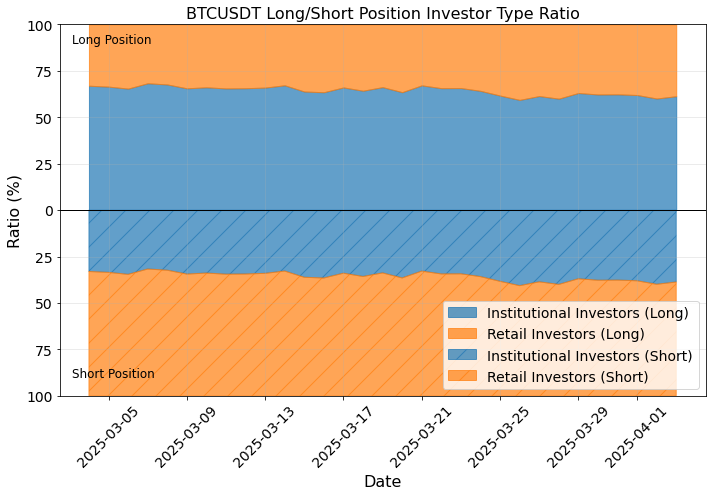

BTCUSDT visualization completed

===== ETHUSDT Investor Type Analysis =====
Long Position: Institutional 72.55%, Retail 27.45%
Short Position: Institutional 27.45%, Retail 72.55%


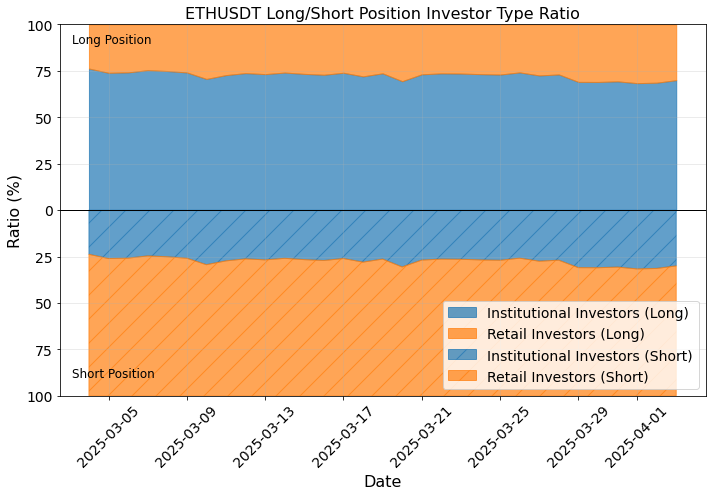

ETHUSDT visualization completed

===== SOLUSDT Investor Type Analysis =====
Long Position: Institutional 67.74%, Retail 32.26%
Short Position: Institutional 32.26%, Retail 67.74%


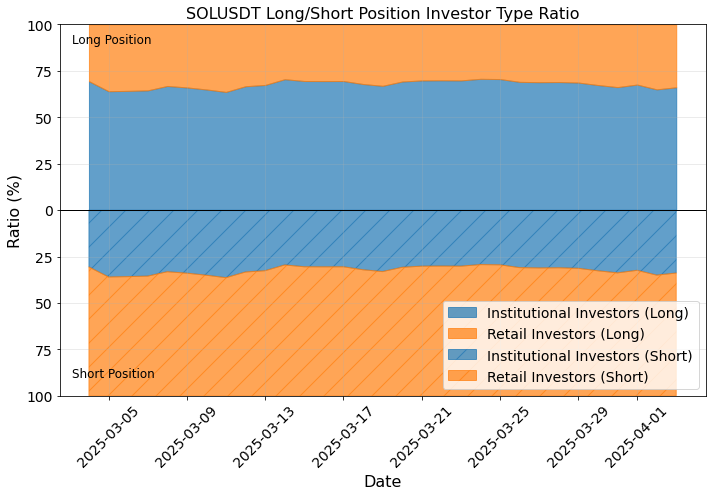

SOLUSDT visualization completed

===== BNBUSDT Investor Type Analysis =====
Long Position: Institutional 53.47%, Retail 46.53%
Short Position: Institutional 46.53%, Retail 53.47%


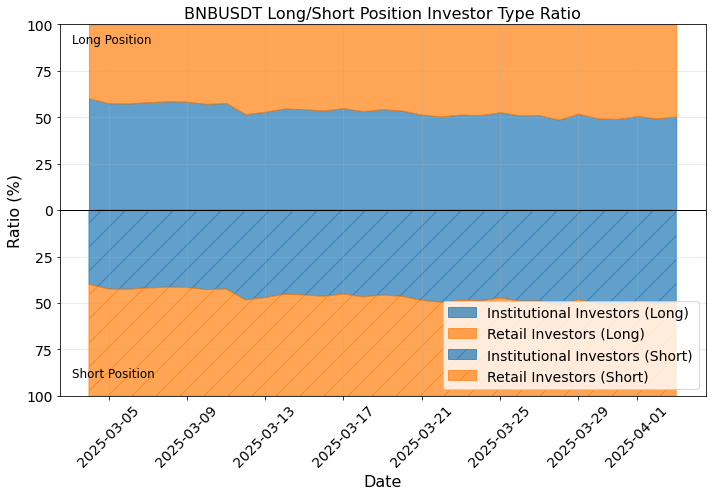

BNBUSDT visualization completed


In [15]:
analyzer = BinanceInvestorAnalyzer()
    
# 분석할 암호화폐 목록
crypto_symbols = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "BNBUSDT"]

# 데이터 가져오기
investor_ratios = analyzer.get_all_investor_ratios(crypto_symbols, period="1d", limit=500)

# 결과 출력 및 시각화
for symbol, data in investor_ratios.items():
    print(f"\n===== {symbol} Investor Type Analysis =====")
    
    # 최신 데이터 출력
    mean = data.loc[:, ['long_institution_ratio', 'long_retail_ratio',
       'short_institution_ratio', 'short_retail_ratio']].mean()
    print(f"Long Position: Institutional {mean['long_institution_ratio']:.2f}%, Retail {mean['long_retail_ratio']:.2f}%")
    print(f"Short Position: Institutional {mean['short_institution_ratio']:.2f}%, Retail {mean['short_retail_ratio']:.2f}%")
    
    # 시각화
    # 3. 롱/숏 투자자 유형 비율 통합 그래프
    combined_plt = analyzer.visualize_combined_investor_ratio(data, symbol)
    combined_plt.show()
    
    plt.close('all')
    print(f"{symbol} visualization completed")